In [35]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
def clonal_selection_rhs(t, y, r_s, r_r, k_kill, carrying_capacity, therapy_on):
    """two-population logistic competition; therapy only kills sensitive cells."""
    n_s, n_r = y
    assert carrying_capacity > 0
    assert therapy_on in (0, 1)

    total = n_s + n_r
    growth_factor = 1 - total / carrying_capacity

    dn_s = r_s * n_s * growth_factor - therapy_on * k_kill * n_s
    dn_r = r_r * n_r * growth_factor
    return [dn_s, dn_r]

In [37]:
def simulate_clonal_selection(
    n_s0, n_r0, r_s, r_r, k_kill, carrying_capacity, therapy_on, t_max, n_points=200
):
    assert n_s0 >= 0 and n_r0 >= 0, "populations must start non-negative"
    assert r_s > 0 and r_r > 0, "growth rates must be positive"

    t_eval = np.linspace(0, t_max, n_points)
    sol = solve_ivp(
        clonal_selection_rhs,
        t_span=(0, t_max),
        y0=[n_s0, n_r0],
        args=(r_s, r_r, k_kill, carrying_capacity, therapy_on),
        t_eval=t_eval,
        method="RK45",
    )
    assert sol.success, f"integration failed: {sol.message}"
    return sol.t, sol.y[0], sol.y[1]

In [38]:
def plot_clonal_selection(t, n_s, n_r, title=""):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(t, n_s, label="cs (sensitive)")
    ax.plot(t, n_r, label="cr (resistant)")
    ax.set_xlabel("time")
    ax.set_ylabel("population")
    ax.set_title(title)
    sns.despine(ax=ax)
    ax.legend(frameon=False, bbox_to_anchor=(1, 1))
    return fig, ax

def plot_population_proportions(t, n_s, n_r, title=""):
    total = n_s + n_r
    assert np.all(total > 0), "total population must be positive to compute proportions"

    prop_s = n_s / total
    prop_r = n_r / total

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(t, prop_s, label="cs (sensitive)")
    ax.plot(t, prop_r, label="cr (resistant)")
    ax.set_xlabel("time")
    ax.set_ylabel("proportion")
    ax.set_ylim(0, 1)
    ax.set_title(title)
    sns.despine(ax=ax)
    ax.legend(frameon=False, bbox_to_anchor=(1, 1))
    return fig, ax

(<Figure size 600x300 with 1 Axes>,
 <Axes: title={'center': 'proportion under therapy'}, xlabel='time', ylabel='proportion'>)

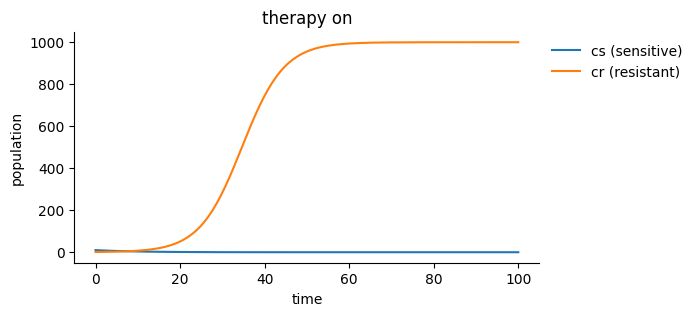

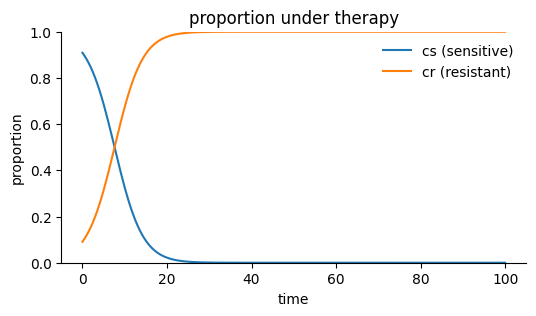

In [39]:
# under therapy, sensitive cells should decline and resistant should take over
t, n_s, n_r = simulate_clonal_selection(
    n_s0=10, n_r0=1, r_s=0.5, r_r=0.2, k_kill=0.6,
    carrying_capacity=1000, therapy_on=1, t_max=100,
)
assert n_r[-1] > n_s[-1], "resistant cells should dominate under sustained therapy"
plot_clonal_selection(t, n_s, n_r, title="therapy on")
plot_population_proportions(t, n_s, n_r, title="proportion under therapy")

## Combining the ABC timescale-separation strategy with two competing clones

The ABC model (`figure4 copy.ipynb`) exploits a homeostatic $A$–$B$ pair that always relaxes back to its off-treatment fixed point $B^*=\mu$, regardless of whether the drug is on or off (a robust-perfect-adaptation property). Net tumor decay only accumulates while $B$ is transiently pushed below $\mu$, so letting $A,B$ reset during $T_{off}$ before pulsing again extracts more cumulative kill than one continuous dose of the same total duration.

Question: **does this still work once the tumor is not a single population but two competing clones?** We replace the single tumor variable $C$ with the clonal-selection pair from above — a drug-**sensitive** clone $C_s$ killed while $B<\mu$ (same mechanism as $C$), and a drug-**insensitive resistant** clone $C_r$ that only competes with $C_s$ for one shared carrying capacity:

$$\dot A = a_1(\mu - B), \qquad \dot B = b_1(t)\,A - b_2 B$$
$$\dot C_s = r_s C_s\Bigl(1-\tfrac{C_s+C_r}{K}\Bigr) - c_2 C_s(\mu-B)^+, \qquad \dot C_r = r_r C_r\Bigl(1-\tfrac{C_s+C_r}{K}\Bigr)$$

Crucially, $A,B$ have **no dependence on $C_s,C_r$** — so whatever pulse schedule the timescale-separation argument picks, it produces exactly the same kill dynamics on $C_s$ whether or not a second clone exists. The only new ingredient is $C_r$: it competes with $C_s$ for capacity, but the treatment never touches it directly. The model is `ABCClonalModel` in `rpa_control/models.py`, compatible with the same `simulate_rpa_on_off` / `simulate_rpa_intermittent` helpers used in `sot_nfl_iffl_demo.ipynb`.

In [40]:
from rpa_control.models import ABCClonalModel, b1, b1_on, A_ss, B_ss
from rpa_control import simulation

print(f'A_ss={A_ss:.3f}  B_ss={B_ss:.3f}  b1 (off)={b1}  b1_on (on)={b1_on}')

A_ss=2.000  B_ss=1.000  b1 (off)=1.0  b1_on (on)=0.5


### Step 1 — does the optimal single-population schedule still shrink $C_s$ the same way?

We reuse the exact growth-vs-decay argument from `figure4 copy.ipynb` Panel C: the decay integral $S(T_{on})$ depends only on the AB parameters (unchanged from before), and the per-capita growth rate of $C_s$ while the population is far below carrying capacity is just $r_s$. Setting $r_s = c_1 = 0.05$ — the same slow growth rate figure4 used — and $T_{off}=13$, we re-derive $T_{on}^{opt}$.

In [48]:
a1_, b2_, mu_, c2_ = 1.0, 2.0, 1.0, 1.0   # AB/kill parameters, same as the ABC model
disc = b2_**2 - 4 * a1_ * b1_on
lam1 = (-b2_ + np.sqrt(disc)) / 2
lam2 = (-b2_ - np.sqrt(disc)) / 2
K1   = b2_ * mu_ * (b1_on / b1 - 1) / (lam1 - lam2)

def decay_analytic(Ton):
    """Analytic cumulative log-decay of Cs over one on-phase (independent of Cr)."""
    Ton = np.asarray(Ton)
    return -c2_ * K1 * (
        np.exp(lam1 * Ton) / lam1 - np.exp(lam2 * Ton) / lam2 - 1 / lam1 + 1 / lam2
    )

r_s_slow = 0.05   # same magnitude as figure4's c1: growth timescale >> AB recovery timescale
T_off    = 10.0

Ton_arr = np.linspace(0.01, 40, 2000)
net_arr = decay_analytic(Ton_arr) - r_s_slow * (Ton_arr + T_off)
Ton_opt = Ton_arr[np.argmax(net_arr)]
print(f'Ton_opt = {Ton_opt:.3f}  (decay={decay_analytic(Ton_opt):.3f}, '
     f'growth={r_s_slow*(Ton_opt+T_off):.3f}, net={net_arr.max():.3f} per cycle)')

Ton_opt = 9.052  (decay=1.830, growth=0.953, net=0.877 per cycle)


In [55]:
def plot_abc_clonal_run(t, y, Ton, Toff, n_cycles, title=''):
    """One figure: A, B, {Cs, Cr, total} on shared log axes, and resistant fraction."""
    A, B, Cs, Cr = y
    total = Cs + Cr
    resist_frac = Cr / total
    on_ranges = [(c * (Ton + Toff), c * (Ton + Toff) + Ton) for c in range(n_cycles)]

    fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True,
                             gridspec_kw={'hspace': 0.1, 'height_ratios': [1, 1, 1.6, 1]})
    for ax in axes:
        for t0, t1 in on_ranges:
            ax.axvspan(t0, t1, color='lightgray', alpha=0.4, lw=0)
        sns.despine(ax=ax)

    axes[0].plot(t, A, color='C1', lw=1.4)
    axes[0].set_ylabel('$A$', fontsize=9)

    axes[1].plot(t, B, color='C0', lw=1.4)
    axes[1].axhline(mu_, color='C0', ls='--', lw=0.9, alpha=0.5, label=r'$\mu$')
    axes[1].set_ylabel('$B$', fontsize=9)
    axes[1].legend(fontsize=7.5, frameon=False, loc='lower right')

    axes[2].plot(t, Cs, label='$C_s$ (sensitive)')
    axes[2].plot(t, Cr, label='$C_r$ (resistant)')
    axes[2].plot(t, total, color='k', ls='--', lw=1.2, label='total')
    axes[2].set_ylabel('population')
    axes[2].set_yscale('log')
    axes[2].legend(fontsize=7.5, frameon=False, loc='center right')

    axes[3].plot(t, resist_frac, color='C3')
    axes[3].set_ylabel('resistant\nfraction')
    axes[3].set_ylim(0, 1)
    axes[3].set_xlabel('time')

    axes[0].set_title(title, fontsize=10)
    plt.tight_layout()
    plt.show()

Now run the actual `ABCClonalModel` — with a small resistant seed already present — at this schedule over a short horizon. If the mechanism transfers unchanged, $C_s$ should show the same repeated-cycle decline as figure4's Panel D.

/tmp/ipykernel_2517015/4226183695.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


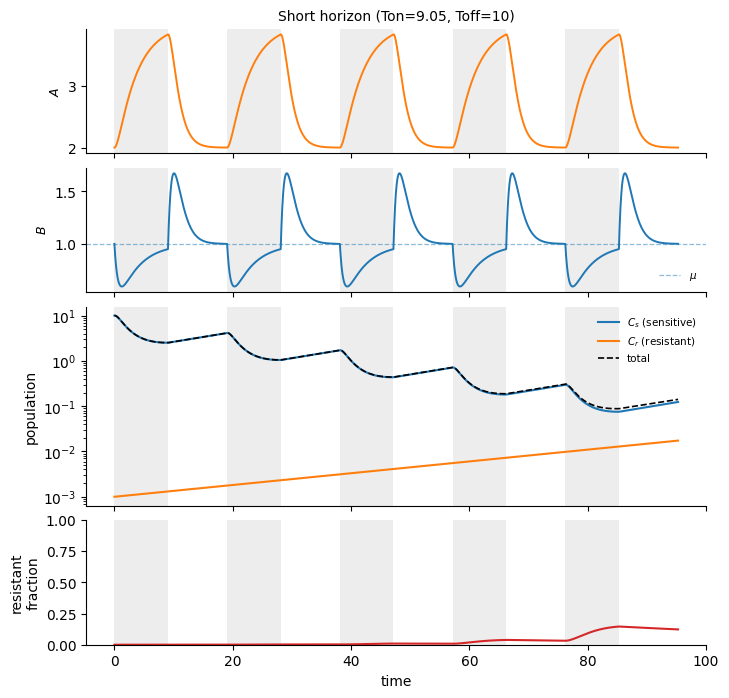

In [53]:
r_r_slow = 0.03   # resistant clone: slower growth (cost of resistance), never killed
model_slow = ABCClonalModel(r_s=r_s_slow, r_r=r_r_slow, carrying_capacity=1000.0)

Cs0, Cr0 = 10.0, 0.001   # small resistant seed present from the start
y0_slow = np.array([A_ss, B_ss, Cs0, Cr0])

T_horizon_short = 100.0
n_cycles_short  = int(T_horizon_short // (Ton_opt + T_off))
t_short, y_short = simulation.simulate_rpa_intermittent(
    model_slow, 'b1', b1_on, b1, t_on=Ton_opt, t_off=T_off,
    n_cycles=n_cycles_short, y0=y0_slow, plot=False)
plot_abc_clonal_run(t_short, y_short, Ton_opt, T_off, n_cycles_short,
                    title=f'Short horizon (Ton={Ton_opt:.2f}, Toff={T_off:.0f})')

### Step 2 — what breaks it: the resistant clone is never touched

$C_r$'s equation doesn't reference $B$ at all, so no choice of $T_{on}/T_{off}$ can slow it down — it only ever sees the shared carrying-capacity term. Extending the exact same schedule over a much longer horizon: $C_s$ keeps getting knocked back every cycle precisely as in Step 1, but $C_r$ grows steadily underneath it and eventually takes over — a relapse driven purely by clonal selection, not by any failure of the timescale-separation logic itself.

/tmp/ipykernel_2517015/2281014087.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


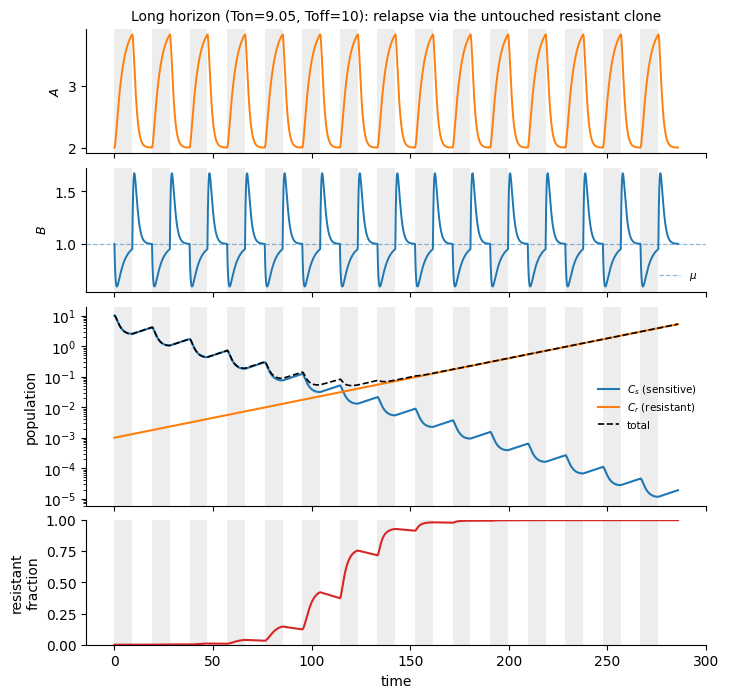

minimum total burden = 0.05 at t=120.2  (started at 10.00, resistant fraction there = 0.717)
final (t=286): total=5.24, resistant fraction=1.000


In [56]:
T_horizon_long = 300.0
n_cycles_long  = int(T_horizon_long // (Ton_opt + T_off))
t_long, y_long = simulation.simulate_rpa_intermittent(
    model_slow, 'b1', b1_on, b1, t_on=Ton_opt, t_off=T_off,
    n_cycles=n_cycles_long, y0=y0_slow, plot=False)
plot_abc_clonal_run(t_long, y_long, Ton_opt, T_off, n_cycles_long,
                    title=f'Long horizon (Ton={Ton_opt:.2f}, Toff={T_off:.0f}): relapse via the untouched resistant clone')

Cs_long, Cr_long = y_long[2], y_long[3]
total_long = Cs_long + Cr_long
i_min = total_long.argmin()
print(f'minimum total burden = {total_long[i_min]:.2f} at t={t_long[i_min]:.1f}  '
     f'(started at {total_long[0]:.2f}, resistant fraction there = {Cr_long[i_min]/total_long[i_min]:.3f})')
print(f'final (t={t_long[-1]:.0f}): total={total_long[-1]:.2f}, resistant fraction={Cr_long[-1]/total_long[-1]:.3f}')

### A second, independent failure mode: growth outracing the maximum achievable decay

Even ignoring $C_r$ entirely, the per-cycle decay $S(T_{on})$ is bounded above (as $T_{on}\to\infty$) by

$$S_\infty = c_2\,\frac{b_2\mu\bigl(1-b_{1,\text{on}}/b_{1,\text{off}}\bigr)}{\lambda_1\lambda_2}$$

If a clone's intrinsic growth rate is comparable to or larger than this bound, growth outpaces the maximum achievable decay for *every* $T_{on}$ — no schedule, however well-timed, can shrink it.

In [45]:
S_inf = -c2_ * K1 * (-1 / lam1 + 1 / lam2)   # decay_analytic(Ton) as Ton -> infinity
print(f'S_inf (max possible log-decay per cycle) = {S_inf:.3f}')

for r_s_test in [0.05, 0.2, 0.5]:
    net_test = decay_analytic(Ton_arr) - r_s_test * (Ton_arr + T_off)
    verdict = 'net decay achievable' if net_test.max() > 0 else 'NO schedule shrinks the tumor'
    print(f'  r_s={r_s_test:4.2f}:  best achievable net decay over all Ton = {net_test.max():+.3f}  ({verdict})')

S_inf (max possible log-decay per cycle) = 2.000
  r_s=0.05:  best achievable net decay over all Ton = +0.727  (net decay achievable)
  r_s=0.20:  best achievable net decay over all Ton = -2.145  (NO schedule shrinks the tumor)
  r_s=0.50:  best achievable net decay over all Ton = -6.505  (NO schedule shrinks the tumor)


**Takeaway.** The timescale-separation strategy itself is unaffected by clonal heterogeneity — it's entirely a property of the $A,B$ subsystem, so the same schedule produces the same per-cycle kill on $C_s$ whether or not a resistant clone exists (Step 1 reproduces figure4's Panel D decline unchanged). What breaks is *durable* tumor control: because $C_r$ is completely decoupled from $B$, any nonzero resistant seed eventually dominates regardless of how well the schedule is tuned for the sensitive population (Step 2) — the single-population argument silently assumed there was nothing else growing in the background. A second, independent failure mode doesn't even need a resistant clone: if a clone's own growth rate approaches the bounded maximum per-cycle decay $S_\infty$, no schedule can shrink it at all.